In [1]:
from collections import defaultdict
import json

# Load data
with open('step_stats.json') as f:
    data = json.load(f)
with open('randla_stats.json') as f2:
    data2 = json.load(f2)

def process_data(data):
    groups = defaultdict(list)
    for entry in data:
        start = tuple(round(x) for x in entry["start_point"])
        goal = tuple(round(x) for x in entry["goal_point"])
        key = (start, goal)
        groups[key].append(entry)

    stats = {}
    for key, group in groups.items():
        total_lengths = [sum(entry["total_length"]) for entry in group]
        dist_togoals = [entry["dist_to_goal"] for entry in group]
        collision_counts = [entry["collision_count"] for entry in group]
        counts = [entry["count"] for entry in group]
        reach_goals = [entry["reach_goal"] for entry in group]

        mean_total_length = sum(total_lengths) / len(total_lengths)
        mean_dist_togoal = sum(dist_togoals) / len(dist_togoals)
        mean_collision = sum(collision_counts) / len(collision_counts)
        mean_count = sum(counts) / len(counts)
        reach_goal_rate = sum(reach_goals) / len(reach_goals)

        stats[key] = {
            "total_length": mean_total_length,
            "dist_togoal": mean_dist_togoal,
            "collision_count": mean_collision,
            "count": mean_count,
            "reach_goal_rate": reach_goal_rate * 100  # percent
        }
    return stats

# Process both datasets
stats1 = process_data(data)
stats2 = process_data(data2)

# Example printout for dataset 2
for key, values in stats2.items():
    print(f"Group {key}:")
    for stat_name, stat_value in values.items():
        if stat_name == "reach_goal_rate":
            print(f"  {stat_name}: {stat_value:.2f}%")
        else:
            print(f"  {stat_name}: {stat_value:.4f}")
    print()


Group ((5, -10), (0, 0)):
  total_length: 33.9499
  dist_togoal: 11.1803
  collision_count: 8.0000
  count: 308.0000
  reach_goal_rate: 80.00%

Group ((5, -10), (17, -7)):
  total_length: 16.7064
  dist_togoal: 12.3693
  collision_count: 1.8333
  count: 182.6667
  reach_goal_rate: 100.00%

Group ((5, -10), (0, -7)):
  total_length: 6.8146
  dist_togoal: 5.8309
  collision_count: 0.0000
  count: 152.5000
  reach_goal_rate: 100.00%

Group ((5, -10), (9, 5)):
  total_length: 24.7409
  dist_togoal: 15.5242
  collision_count: 1.6667
  count: 226.0000
  reach_goal_rate: 100.00%

Group ((0, 0), (5, -10)):
  total_length: 24.6844
  dist_togoal: 11.1804
  collision_count: 0.0000
  count: 424.5000
  reach_goal_rate: 100.00%

Group ((0, 0), (17, -7)):
  total_length: 31.4318
  dist_togoal: 18.3848
  collision_count: 4.6667
  count: 352.0000
  reach_goal_rate: 100.00%

Group ((0, 0), (0, -7)):
  total_length: 23.8165
  dist_togoal: 6.9887
  collision_count: 0.8333
  count: 444.0000
  reach_goal_ra

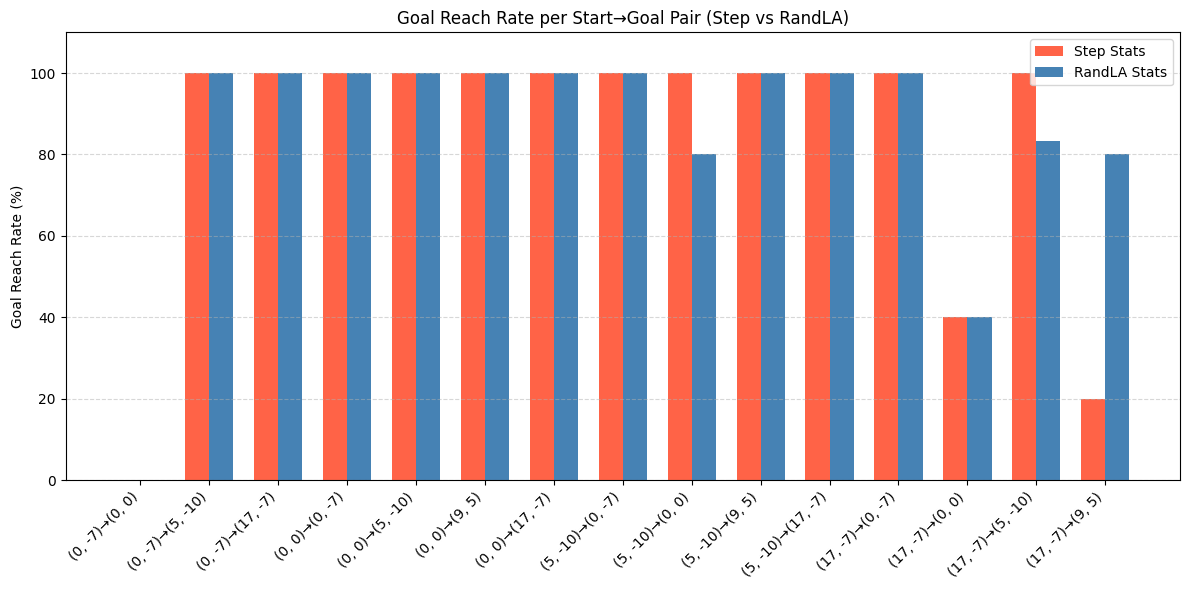

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Combine all keys from both stats
all_keys = sorted(set(stats1.keys()).union(stats2.keys()))

pairs = [f"{start}→{goal}" for (start, goal) in all_keys]
step_rates = [stats1.get(key, {}).get("reach_goal_rate", 0) for key in all_keys]
randla_rates = [stats2.get(key, {}).get("reach_goal_rate", 0) for key in all_keys]

x = np.arange(len(pairs))  # label locations
width = 0.35  # width of the bars

plt.figure(figsize=(max(12, len(pairs)*0.6), 6))
plt.bar(x - width/2, step_rates, width, label='Step Stats', color='tomato')
plt.bar(x + width/2, randla_rates, width, label='RandLA Stats', color='steelblue')

plt.xticks(x, pairs, rotation=45, ha='right')
plt.ylabel("Goal Reach Rate (%)")
plt.ylim(0, 110)
plt.title("Goal Reach Rate per Start→Goal Pair (Step vs RandLA)")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


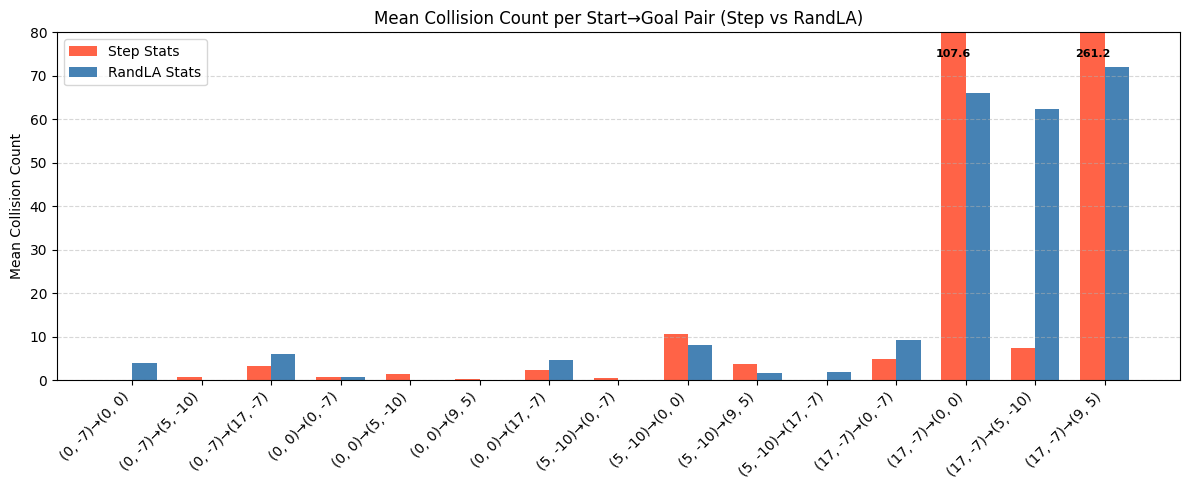

In [22]:
import matplotlib.pyplot as plt
import numpy as np

all_keys = sorted(set(stats1.keys()).union(stats2.keys()))
pairs = [f"{start}→{goal}" for (start, goal) in all_keys]

step_collision_means = [stats1.get(key, {}).get("collision_count", 0) for key in all_keys]
randla_collision_means = [stats2.get(key, {}).get("collision_count", 0) for key in all_keys]

x = np.arange(len(pairs))
width = 0.35

plt.figure(figsize=(max(12, len(pairs)*0.6), 5))
bars1 = plt.bar(x - width/2, step_collision_means, width, label='Step Stats', color='tomato')
bars2 = plt.bar(x + width/2, randla_collision_means, width, label='RandLA Stats', color='steelblue')

plt.xticks(x, pairs, rotation=45, ha='right')
plt.ylabel("Mean Collision Count")
plt.title("Mean Collision Count per Start→Goal Pair (Step vs RandLA)")
plt.legend()

ylim_val = 80
plt.ylim(0, ylim_val)  # Fixed y-limit

plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

def label_only_over_limit(bars, limit=ylim_val, label_y=75):
    for bar in bars:
        height = bar.get_height()
        if height > limit:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                label_y,
                f'{height:.1f}',
                ha='center',
                va='center',
                fontsize=8,
                fontweight='bold',
                color='black'
            )

label_only_over_limit(bars1)
label_only_over_limit(bars2)

plt.show()


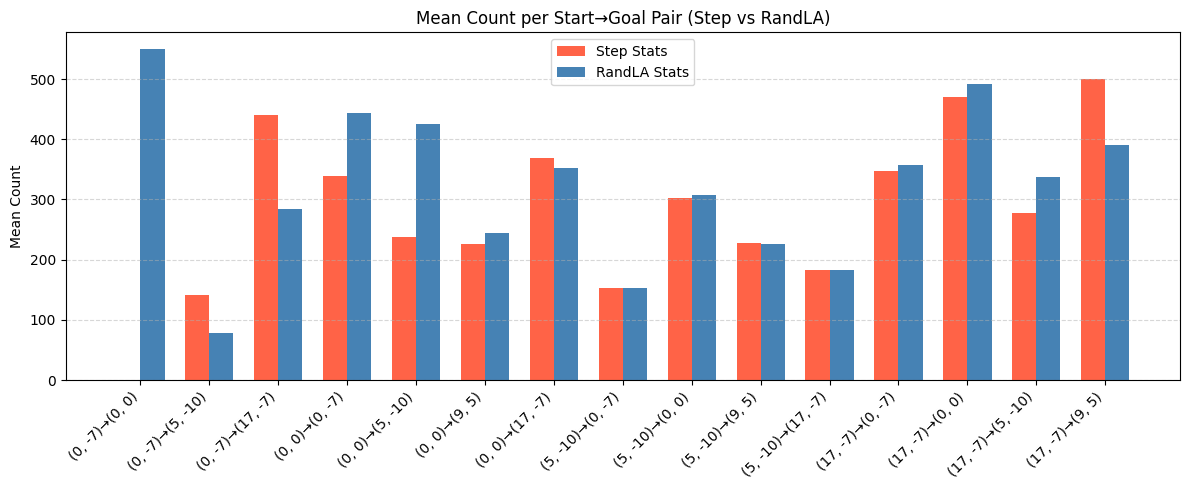

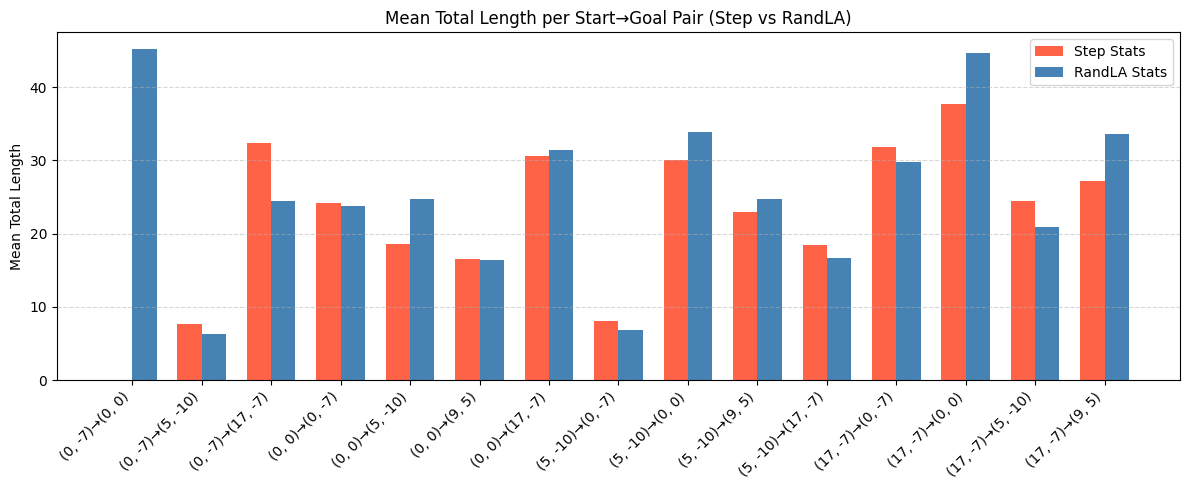

In [24]:
import matplotlib.pyplot as plt
import numpy as np

all_keys = sorted(set(stats1.keys()).union(stats2.keys()))
pairs = [f"{start}→{goal}" for (start, goal) in all_keys]

step_counts = [stats1.get(key, {}).get("count", 0) for key in all_keys]
randla_counts = [stats2.get(key, {}).get("count", 0) for key in all_keys]

step_lengths = [stats1.get(key, {}).get("total_length", 0) for key in all_keys]
randla_lengths = [stats2.get(key, {}).get("total_length", 0) for key in all_keys]

x = np.arange(len(pairs))
width = 0.35

# Plot Count comparison
plt.figure(figsize=(max(12, len(pairs)*0.6), 5))
bars1 = plt.bar(x - width/2, step_counts, width, label='Step Stats', color='tomato')
bars2 = plt.bar(x + width/2, randla_counts, width, label='RandLA Stats', color='steelblue')

plt.xticks(x, pairs, rotation=45, ha='right')
plt.ylabel("Mean Count")
plt.title("Mean Count per Start→Goal Pair (Step vs RandLA)")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot Total Length comparison
plt.figure(figsize=(max(12, len(pairs)*0.6), 5))
bars1 = plt.bar(x - width/2, step_lengths, width, label='Step Stats', color='tomato')
bars2 = plt.bar(x + width/2, randla_lengths, width, label='RandLA Stats', color='steelblue')

plt.xticks(x, pairs, rotation=45, ha='right')
plt.ylabel("Mean Total Length")
plt.title("Mean Total Length per Start→Goal Pair (Step vs RandLA)")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


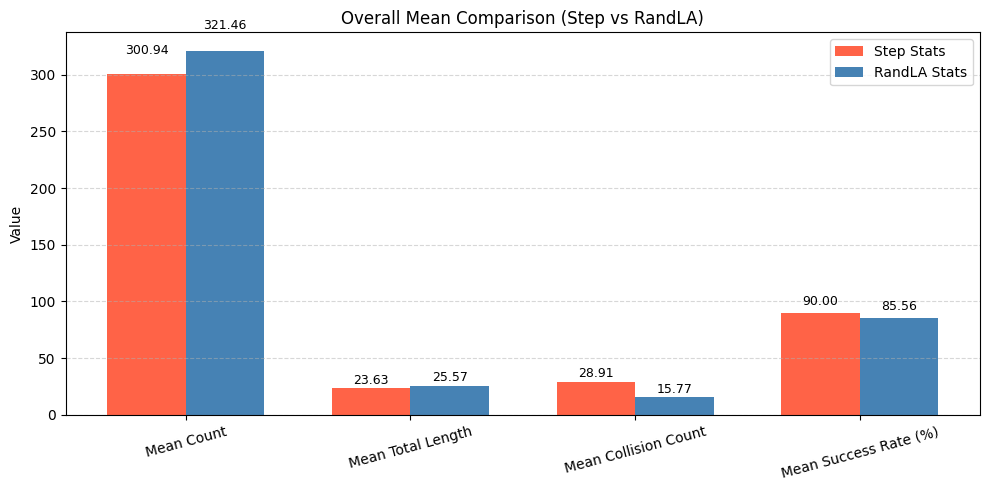

In [27]:
# Extract reach_goal_rate (success rate) from stats1 and stats2
step_success_rates_all = [v.get("reach_goal_rate", 0) for v in stats1.values()]
randla_success_rates_all = [v.get("reach_goal_rate", 0) for v in stats2.values()]

# Calculate means
mean_step_success = np.mean(step_success_rates_all) if step_success_rates_all else 0
mean_randla_success = np.mean(randla_success_rates_all) if randla_success_rates_all else 0

# Extend metrics and data lists
metrics = ['Mean Count', 'Mean Total Length', 'Mean Collision Count', 'Mean Success Rate (%)']
step_means = [mean_step_count, mean_step_length, mean_step_collision, mean_step_success]
randla_means = [mean_randla_count, mean_randla_length, mean_randla_collision, mean_randla_success]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 5))
bars1 = plt.bar(x - width/2, step_means, width, label='Step Stats', color='tomato')
bars2 = plt.bar(x + width/2, randla_means, width, label='RandLA Stats', color='steelblue')

plt.xticks(x, metrics, rotation=15)
plt.ylabel('Value')
plt.title('Overall Mean Comparison (Step vs RandLA)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.05 * height,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()
